## ** SALES DATA TASKS**      

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **IMPORT RAW DATA  **

In [ ]:
df_customers = pd.read_csv(r"C:\Users\rithu\AppData\Local\Packages\LocalState\sessions\transfers\2026-16\big_customers.csv")
df_orders = pd.read_csv(r"C:\Users\rithu\AppData\Local\Packages\LocalState\sessions\transfers\2026-16\big_order_items.csv")
df_order_items = pd.read_csv(r"C:\Users\rithu\OneDrive\Documents\big_order_items.csv")
df_payments = pd.read_csv(r"C:\Users\rithu\AppData\Local\Packages\LocalState\sessions\transfers\2026-16\big_payments.csv")
df_products= pd.read_csv(r"C:\Users\rithu\AppData\Local\Packages\LocalState\sessions\transfers\2026-16\big_products.csv")


## ** LOAD DATA **

In [22]:
print("Customers Head ")
print(df_customers.head())

print("\n Orders Head ")
print(df_orders.head())

print("\n Order Items Head ")
print(df_order_items.head())

Customers Head 
   Customer_ID Customer_Name         City
0            1    Customer_1      Chennai
1            2    Customer_2        Salem
2            3    Customer_3   Coimbatore
3            4    Customer_4   COIMBATORE
4            5    Customer_5  Tirunelveli

 Orders Head 
   Order_ID  Product_ID  Quantity Discount
0      1001         148         5        5
1      1002         127         4       10
2      1002         111         3       10
3      1002         147         3      ten
4      1002         139         1        0

 Order Items Head 
   Order_ID  Product_ID  Quantity Discount
0      1001         148         5        5
1      1002         127         4       10
2      1002         111         3       10
3      1002         147         3      ten
4      1002         139         1        0


## ** EXPLORE DATA **

In [23]:
# 1. Check shape of dataset (Rows, Columns)
print(" Dataset Shape ")
print("Customers Shape:", df_customers.shape)
print("Orders Shape:", df_orders.shape)
print("Order Items Shape:", df_order_items.shape)

 Dataset Shape 
Customers Shape: (215, 3)
Orders Shape: (974, 4)
Order Items Shape: (974, 4)


In [24]:
# 2. Display column names
print("\n Column Names ")
print("Customers Columns:", df_customers.columns)
print("Orders Columns:", df_orders.columns)



 Column Names 
Customers Columns: Index(['Customer_ID', 'Customer_Name', 'City'], dtype='str')
Orders Columns: Index(['Order_ID', 'Product_ID', 'Quantity', 'Discount'], dtype='str')


In [25]:
# 3. Use info() to understand data
print("\n Dataset Info ")
df_customers.info()
df_orders.info()
df_order_items.info()


 Dataset Info 
<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Customer_ID    215 non-null    int64
 1   Customer_Name  205 non-null    str  
 2   City           201 non-null    str  
dtypes: int64(1), str(2)
memory usage: 5.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Order_ID    974 non-null    int64
 1   Product_ID  974 non-null    int64
 2   Quantity    974 non-null    int64
 3   Discount    805 non-null    str  
dtypes: int64(3), str(1)
memory usage: 30.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Order_ID    974 non-null    int64
 1   Product_ID  974 non-null    int64
 2   Quantit

## ** SELECT & FILTER **

In [26]:
# 1. Select Customer_Name and City columns
customer_subset = df_customers[['Customer_Name', 'City']]
print("Selected Columns")
display(customer_subset.head())

Selected Columns


,Customer_Name,City
0,Customer_1,Chennai
1,Customer_2,Salem
2,Customer_3,Coimbatore
3,Customer_4,COIMBATORE
4,Customer_5,Tirunelveli


In [27]:
# 2. Filter customers from Chennai
chennai_customers = df_customers[df_customers['City'] == 'Chennai']
print("\nCustomers from Chennai")
display(chennai_customers.head())


Customers from Chennai


,Customer_ID,Customer_Name,City
0,1,Customer_1,Chennai
10,11,Customer_11,Chennai
17,18,Customer_18,Chennai
37,38,Customer_38,Chennai
38,39,Customer_39,Chennai


## ** BASIC CLEANING **


In [28]:
# 1. Replace empty Customer_Name with 'Unknown'
df_customers['Customer_Name'].fillna('Unknown', inplace=True)



C:\Users\Shobhika\AppData\Local\Temp\ipykernel_12940\1105196011.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_customers['Customer_Name'].fillna('Unknown', inplace=True)


0        Customer_1
1        Customer_2
2        Customer_3
3        Customer_4
4        Customer_5
           ...     
210    Customer_172
211     Customer_19
212     Customer_12
213     Customer_90
214    Customer_111
Name: Customer_Name, Length: 215, dtype: str

In [31]:
# 2. Standardize City names (e.g., 'chennai' -> 'Chennai')
df_customers['City'] = df_customers['City'].str.title()
# check data
print("Data after Cleaning")
display(df_customers.head())



Data after Cleaning


,Customer_ID,Customer_Name,City
0,1,Customer_1,Chennai
1,2,Customer_2,Salem
2,3,Customer_3,Coimbatore
3,4,Customer_4,Coimbatore
4,5,Customer_5,Tirunelveli


## ** REMOVE DUPLICATES **

In [32]:
# Check for duplicate rows 
print("Duplicate Count")
print("Customers:", df_customers.duplicated().sum())
print("Orders:", df_orders.duplicated().sum())
print("Order Items:", df_order_items.duplicated().sum())



Duplicate Count
Customers: 15
Orders: 31
Order Items: 31


In [34]:


# Remove duplicates 
df_customers.drop_duplicates(inplace=True)
df_orders.drop_duplicates(inplace=True)
df_order_items.drop_duplicates(inplace=True)

print("\n Duplicates Removed!")


 Duplicates Removed!


## ** CREATE NEW COLUMN **

In [44]:
# 1.  table 'Product_ID'  merge 
merged_df = pd.merge(df_order_items, df_products, on='Product_ID')

# 2.Total calculate
merged_df['Total'] = merged_df['Quantity'] * merged_df['Base_Price']

# 3. Check 
print("'Total' column created successfully ")
display(merged_df.head())

'Total' column created successfully 


,Order_ID,Product_ID,Quantity,Discount,Product_Name,Category,Base_Price,Total
0,1001,148,5,5,Product_148,HOME,37827,189135
1,1001,148,5,5,Product_148,HOME,37827,189135
2,1002,127,4,10,Product_127,electronics,126,504
3,1002,111,3,10,Product_111,Home,28365,85095
4,1002,147,3,ten,Product_147,Fashion,27260,81780


## ** GROUP BY **

In [45]:
# 1. Group by Product_Name and sum the Total
product_sales = merged_df.groupby('Product_Name')['Total'].sum().reset_index()

print("Total Sales Per Product")
display(product_sales)

Total Sales Per Product


,Product_Name,Total
0,Product_101,3425208
1,Product_102,499070
2,Product_103,1970124
3,Product_104,923615
4,Product_105,2560250
5,Product_106,16380
6,Product_107,1344706
7,Product_108,1653680
8,Product_109,3823758
9,Product_110,1223128


In [ ]:
# 1. Merge Order Items and Products
category_df = pd.merge(df_order_items, df_products, on='Product_ID')

# 2. Calculate Total for each row
category_df['Total'] = category_df['Quantity'] * category_df['Base_Price']

# 3. Group by Category
category_sales = category_df.groupby('Category')['Total'].sum().reset_index()

print(" Sales by Product Category ")
display(category_sales)

--- Sales by Product Category ---


,Category,Total
0,Accessories,21433042
1,Electronics,10239400
2,Fashion,24987042
3,HOME,17588797
4,Home,17207675
5,electronics,7912334


In [64]:
# Group by Payment Mode
payment_analysis = df_payments.groupby('Payment_Mode')['Order_ID'].count().reset_index()
payment_analysis.columns = ['Payment_Mode', 'Order_Count']

print("--- Payment Mode Popularity ---")
display(payment_analysis)

--- Payment Mode Popularity ---


,Payment_Mode,Order_Count
0,CARD,75
1,Card,55
2,Cash,63
3,UPI,67
4,upi,60


## **SIMPLE VISUALIZATION **

C:\Users\Shobhika\AppData\Local\Temp\ipykernel_12940\2077384340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Category', y='Total', palette='viridis')


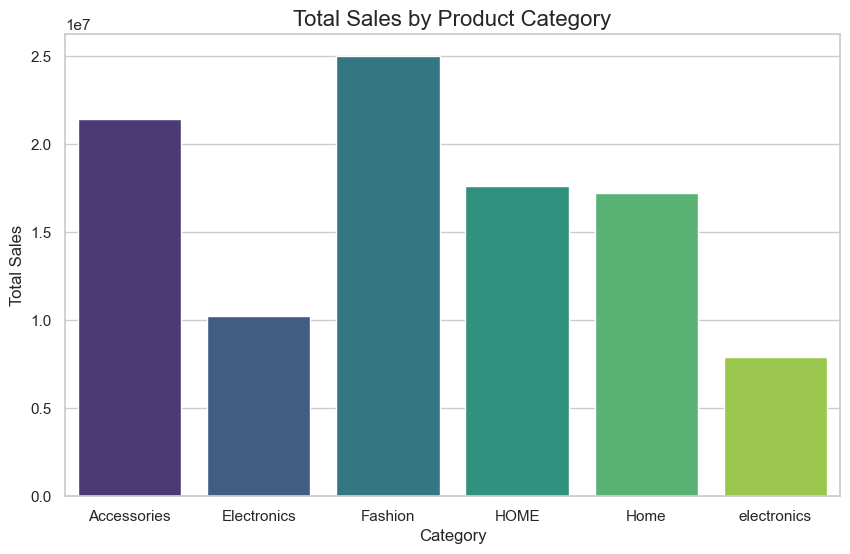

In [65]:
# Set the plot style
sns.set_theme(style="whitegrid")

# Create a figure
plt.figure(figsize=(10, 6))

# Plotting the bar chart
sns.barplot(data=category_sales, x='Category', y='Total', palette='viridis')

# Adding labels and title
plt.title('Total Sales by Product Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

plt.show()

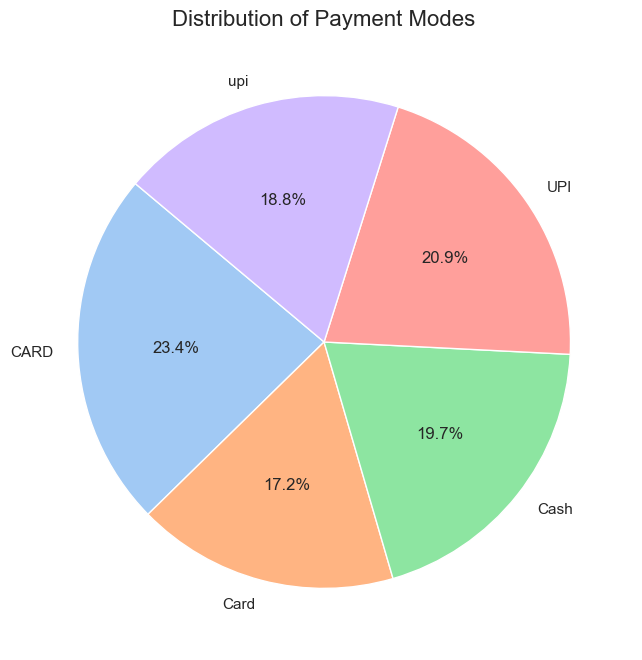

In [66]:
# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(payment_analysis['Order_Count'], labels=payment_analysis['Payment_Mode'], 
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))

plt.title('Distribution of Payment Modes', fontsize=16)
plt.show()

## ** hii **